In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.datasets import imdb                  # ← DIRECT IMPORT!
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [3]:
# No CSV needed! Keras has IMDB built-in!
vocab_size = 10000   # Only top 10,000 most common words

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples      :", len(X_train))
print("Testing samples       :", len(X_test))
print("\nSample review (as numbers already):")
print(X_train[0][:20], "...")   # first 20 numbers of first review
print("\nSample label (0=negative, 1=positive):", y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 10s 1us/step
Training samples      : 25000
Testing samples       : 25000

Sample review (as numbers already):
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25] ...

Sample label (0=negative, 1=positive): 1


In [5]:
# All reviews made exactly 250 words long
max_len = 250

X_train = pad_sequences(X_train, maxlen=max_len, padding='pre', truncating='pre')
X_test  = pad_sequences(X_test,  maxlen=max_len, padding='pre', truncating='pre')

print("\nX_train shape after padding:", X_train.shape)
print("X_test  shape after padding:", X_test.shape)



X_train shape after padding: (25000, 250)
X_test  shape after padding: (25000, 250)


In [11]:
# ---- STEP 4: Build the Model Architecture ----
model = Sequential()

# Embedding Layer — input_length REMOVED (deprecated in new Keras)
model.add(Embedding(input_dim=vocab_size, output_dim=128))

# First Bidirectional LSTM Layer
model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(Dropout(0.3))

# Second Bidirectional LSTM Layer
model.add(Bidirectional(LSTM(32)))
model.add(Dropout(0.3))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_4 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_5 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [13]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [15]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 542s 3s/step - accuracy: 0.6637 - loss: 0.5662 - val_accuracy: 0.8728 - val_loss: 0.3043
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 417s 3s/step - accuracy: 0.9140 - loss: 0.2299 - val_accuracy: 0.8544 - val_loss: 0.3407
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 504s 3s/step - accuracy: 0.9483 - loss: 0.1503 - val_accuracy: 0.8550 - val_loss: 0.3793
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 537s 3s/step - accuracy: 0.9648 - loss: 0.1081 - val_accuracy: 0.8608 - val_loss: 0.4188


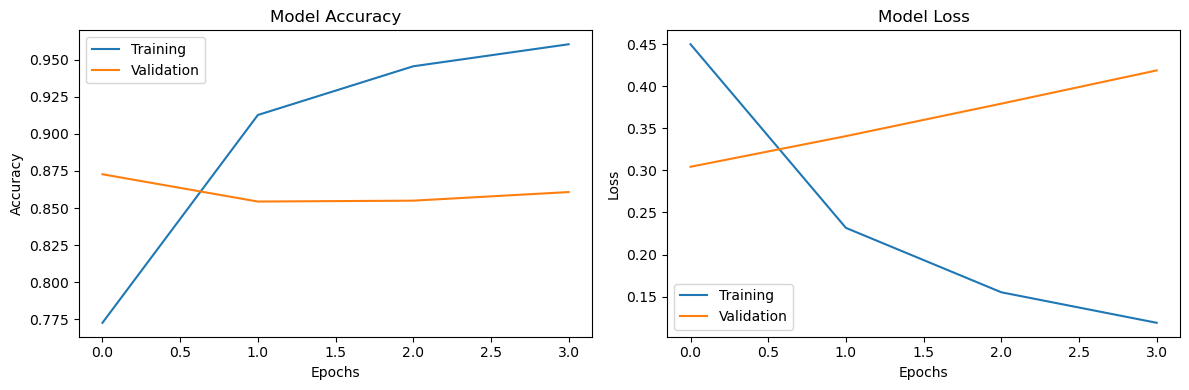

In [17]:
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Training', 'Validation'])

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Training', 'Validation'])

plt.tight_layout()
plt.show()


In [19]:
loss, acc = model.evaluate(X_test, y_test, batch_size=128)
print(f'Test accuracy: {acc:.4f}, Test loss: {loss:.4f}')

196/196 ━━━━━━━━━━━━━━━━━━━━ 60s 307ms/step - accuracy: 0.8691 - loss: 0.3088
Test accuracy: 0.8691, Test loss: 0.3075
